# **Unsupervised Learning Final Project**

# **Background**

This dataset comes from the [MLOmic: Cancer Multi-Omics Database for Machine Learning](https://figshare.com/articles/dataset/MLOmics_Cancer_Multi-Omics_Database_for_Machine_Learning/28729127). It includes data from over 8000 patients covering 32 different cancer types and mutliple data types: Copy Number Variations (CNV), messenger RNA (mRNA), methylated DNA (methy), and microRNA (miRNA). These types represent different views into the microbiological state of the patient through DNA and RNA. This study will focus on just mRNA data which represents the relative amounts of expression of a particular gene. In cancer cells regulation of certain genes are altered resulting in a different state of mRNA. 

The challenge in cancer diagnostics is that every cancer is unique to the individual and there are  thousands of genes that can be expressed. This is where unsupervised learning techniques can be helpful: in reducing the dimensionality space to allow for predicition on cancer types. In this project we will utilize matrix factorization techniques to reduce feature dimensionality and then perform logistic regression to see if we can realibly predict cancer subtypes based on mRNA data.

In [36]:
# Loading Dependencies
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,  classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import AgglomerativeClustering, KMeans
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## **EDA**

Before we start building the model let's get an idea of how this data is organized.

In [37]:
# Data for COAD datasets - If running on your own download from figshare or github posted in citations
LABEL_PATH = '/Users/jakebloom/python_envs/Cancer/Cancer-Multi-Omics-Benchmark/Main_Dataset/Classification_datasets/Pan-cancer_label_num.csv'
RNA_PATH = '/Users/jakebloom/python_envs/Cancer/Cancer-Multi-Omics-Benchmark/Main_Dataset/Classification_datasets/Pan-cancer_mRNA.csv'

labels = pd.read_csv(LABEL_PATH)
mRNA = pd.read_csv(RNA_PATH)
print('Unique Labels: ', labels.Label.unique())
print('Number of Samples: ', len(labels))

Unique Labels:  [19 29 24 15  2  3 10 14 28  1 16 27  8 13 21 25 11 30  5 17  7 31 23 12
 20 22 26  6  0  9 18  4]
Number of Samples:  8314


So we have 32 cancer subtypes as made clear in the github repo as well as 8314 patient samples. Below we will create a dictionary to match labels to cancer subtype abbreviations. To read more about the abbreviations you can reference the [README here](https://github.com/chenzRG/Cancer-Multi-Omics-Benchmark?tab=readme-ov-file#installations).

In [38]:
# Dictionary for labels
num_to_abbr = {
    0: 'LAML', 1: 'ACC', 2: 'BLCA', 3: 'LGG', 4: 'BRCA', 5: 'CESC', 6: 'CHOL', 7: 'COAD',
    8: 'DLBC', 9: 'ESCA', 10: 'HNSC', 11: 'KICH', 12: 'KIRC', 13: 'KIRP', 14: 'LIHC', 15: 'LUAD', 
    16: 'LUSC', 17: 'MESO', 18: 'OV', 19: 'PAAD', 20: 'PCPG', 21: 'PRAD', 22: 'READ', 23: 'SARC',
    24: 'SKCM', 25: 'STAD', 26: 'TGCT', 27: 'THYM', 28: 'THCA', 29: 'UCS', 30: 'UCEC', 31: 'UVM'
}

Let's get a view of the distribution of the cancer types: 

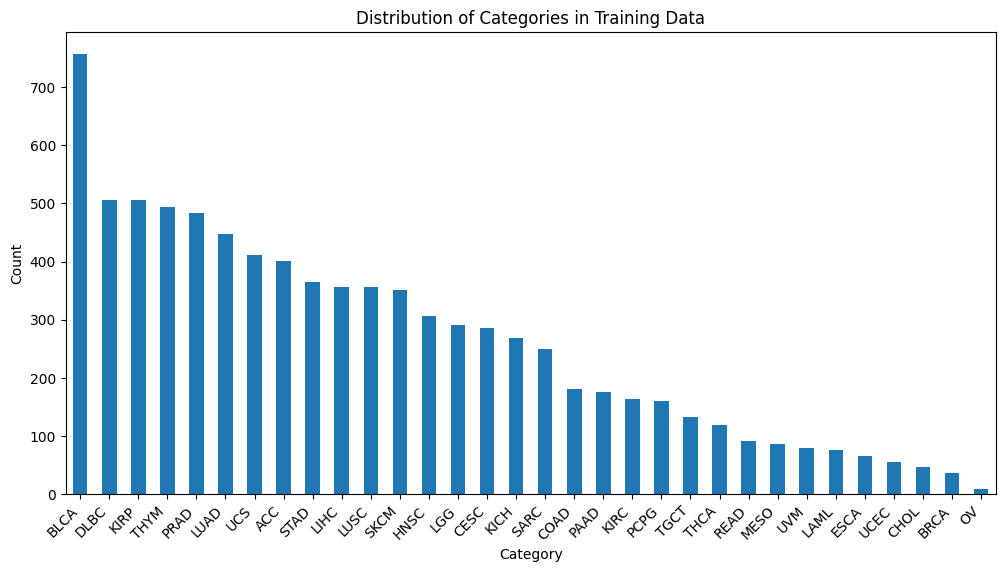

In [39]:
label_counts = labels['Label'].value_counts()
label_counts.index = label_counts.index.map(num_to_abbr)
plt.figure(figsize=(12, 6))
label_counts.plot.bar()
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Categories in Training Data')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.show()

Next we need to clean and prep the data. We will fill any nan values with 0, rotate the x data so its aligned with the labels, and then split the data into training, validation, and test data. 

In [40]:
# Transposing X data to align with the y a
mRNA_nosamp = mRNA.iloc[:,1:]
mRNA_nosamp_filled = mRNA_nosamp.fillna(0)
mRNA_t = mRNA_nosamp_filled.T
labels_series = labels['Label']
mRNA_t.head()

# Reserving 15% of data for testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    mRNA_t, labels_series, test_size=0.15, random_state=102, stratify=labels_series
)
# Taking 20% of the remaining data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=102, stratify=y_train_val
)




Let's plot a histogram of 100 random  patient's mRNA data to get an idea of the values.

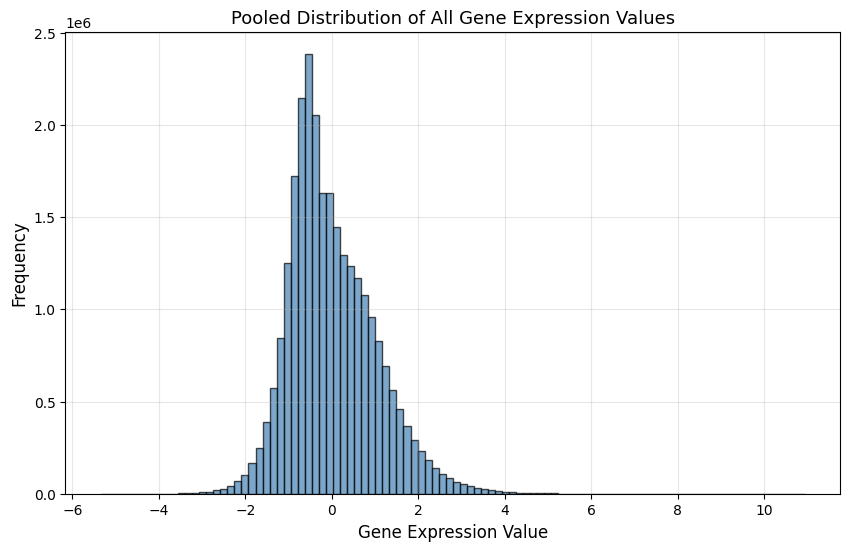

In [41]:
#Plotting the mRNA values
all_values = mRNA_t.values.flatten()

all_values = all_values[~np.isnan(all_values)]

plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Gene Expression Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Pooled Distribution of All Gene Expression Values', 
          fontsize=13)
plt.grid(alpha=0.3)
plt.show()

## **Analysis**
### **Model Design**
Since the data is centered near zero and contains some negative values we will use Singular Value Decomposition (SVD). We will use sklearns Truncated SVD to operate in with more memory effeciency. After SVD we will use the compressed matrix to predict the cancer type using a logistic regression. 

In [42]:
# Dimensionality Reduction via TruncatedSVD
n = 10
svd = TruncatedSVD(n_components=n, algorithm='randomized', n_iter=100, 
                   n_oversamples=10, power_iteration_normalizer='auto', 
                   random_state=102)

df_svd = svd.fit_transform(X_train)

In [43]:
#Building the logistic regression
predictor = LogisticRegression(max_iter=1000, random_state=42)
predictor.fit(df_svd, y_train)

/Users/jakebloom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [44]:
val_svd  = svd.transform(X_val)
val_pred = predictor.predict(val_svd)


In [45]:
print(f"Validation Accuracy: {accuracy_score(y_val, val_pred):.4f}")

Validation Accuracy: 0.8854


### **Optimizing**
With a relatively low dimensional model (N_components = 10) we are able to achieve a relatively high validation accuracy of ~88%. Next to tune the model further we will iterate through the n_components in the SVD and track validation accuracy.

In [46]:
# Iterating Through Different Matrix Sizes to Monitor Performance 
N = [5, 10, 15, 20, 25, 50, 75, 100]
acc_scores = []
for n in N:
    print(n)
    svd = TruncatedSVD(n_components=n, algorithm='randomized', n_iter=1000, 
                    n_oversamples=10, power_iteration_normalizer='auto', 
                    random_state=102)

    df_svd = svd.fit_transform(X_train)
    predictor = LogisticRegression(max_iter=10000, random_state=42)
    predictor.fit(df_svd, y_train)
    val_svd  = svd.transform(X_val)
    val_pred = predictor.predict(val_svd)
    acc_scores.append(accuracy_score(y_val, val_pred))




5
10
15
20
25
50
75
100


Text(0.5, 1.0, 'Validation Data Accuracy vs SVD Components')

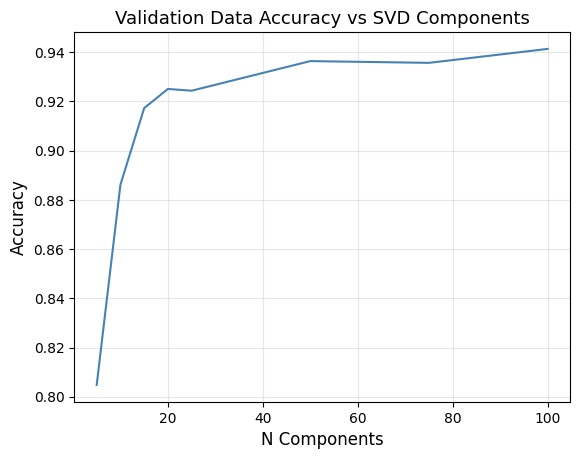

In [47]:
plt.plot(N, acc_scores, color='steelblue')
plt.grid(alpha=0.3)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('N Components', fontsize=12)
plt.title('Validation Data Accuracy vs SVD Components', fontsize=13)

Here we can see a rapid improvment in the model accuracy going from n_components = 5 through 25. For the best model we will choose the N = 40 components as it it near the "elbow" of the accuracy curve. This will strike a good balance of limiting model complexity while keeping accuracy high (~93%).

In [48]:
#Isolating the best SVD and plotting a confusion matrix
best_SVD = TruncatedSVD(n_components=50, algorithm='randomized', n_iter=100, 
                    n_oversamples=10, power_iteration_normalizer='auto', 
                    random_state=102)

df_svd_best = best_SVD.fit_transform(X_train)
predictor_svd = LogisticRegression(max_iter=10000, random_state=42)
predictor_svd.fit(df_svd_best, y_train)
val_svd  = best_SVD.transform(X_val)
val_pred = predictor_svd.predict(val_svd)
accuracy_score(y_val, val_pred)




0.9363507779349364

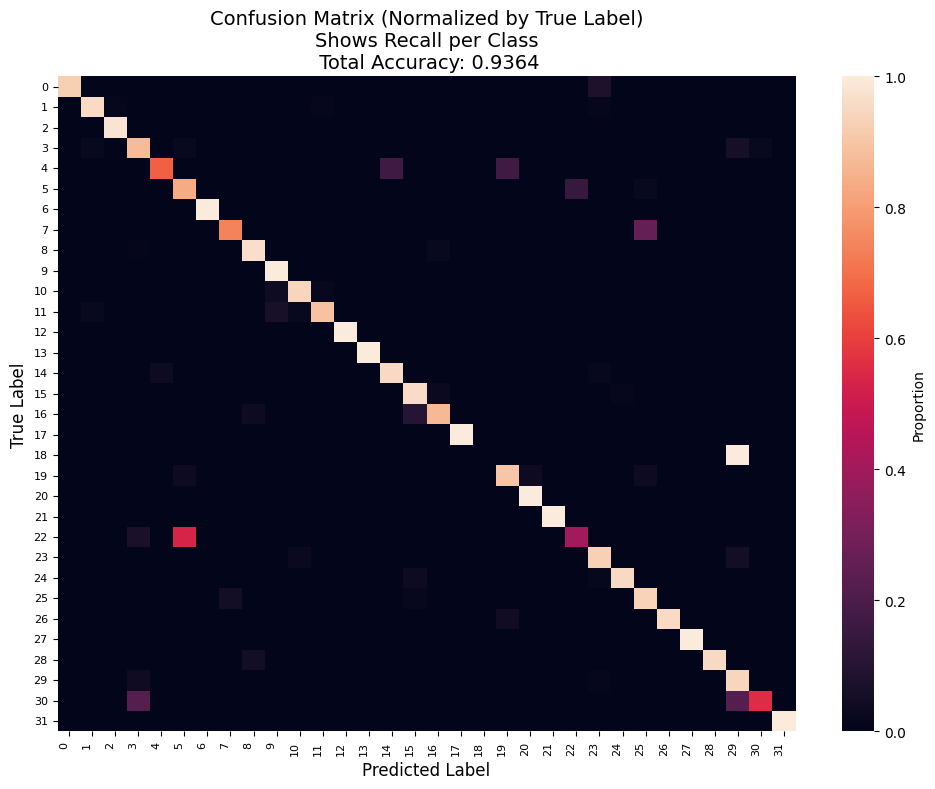

In [49]:
# Create confusion matrix
cm = confusion_matrix(y_val, val_pred)
class_labels = np.unique(y_train)

# Normalize by true labels (rows) to show recall per class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, figsize=(10, 8))

sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='rocket', 
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes, vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
axes.set_title(f'Confusion Matrix (Normalized by True Label)\nShows Recall per Class\n Total Accuracy: {accuracy_score(y_val, val_pred):.4f}', 
                  fontsize=14)
axes.set_xlabel('Predicted Label', fontsize=12)
axes.set_ylabel('True Label', fontsize=12)
axes.set_xticklabels(axes.get_xticklabels(), rotation=90, ha='right', fontsize=8)
axes.set_yticklabels(axes.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## **Results**
Here we are plotting a confusion matrix of the validation data predictions. I have plotted the proportion of labels instead of directly plotting label counts due to the uneven distribution of catergories. Here we see a large amount of predictions falling on the diagonal - meaning we have predicted correctly. An important outlier is the high proportion of misses on correctly predicting 18, 22, and 30 data. These correspond to the OV, READ, and UCEC cancer types. All three of these had low represenation in the data set. 

Next let's plot a confusion matrix of the test data predictions.

In [50]:
#Test data accuracy
test_svd  = best_SVD.transform(X_test)
test_pred = predictor_svd.predict(test_svd)
accuracy_score(y_test, test_pred)


0.9399038461538461

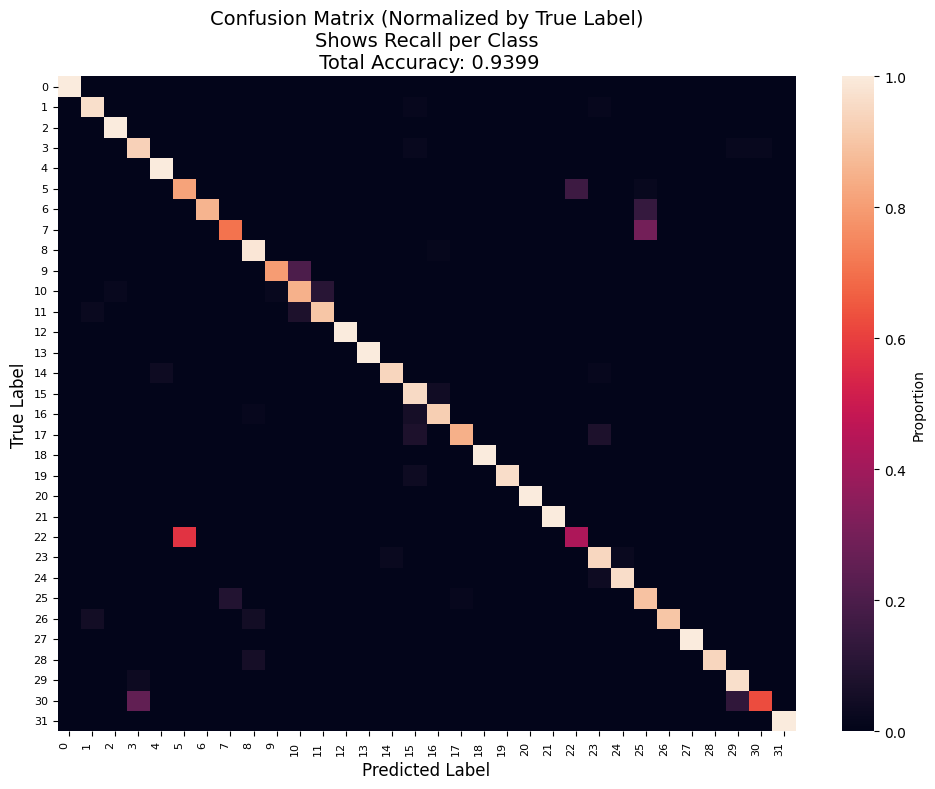

In [51]:
# Create confusion matrix
cm = confusion_matrix(y_test, test_pred)
class_labels = np.unique(y_train)

# Normalize by true labels (rows) to show recall per class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, figsize=(10, 8))

sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='rocket', 
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes, vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
axes.set_title(f'Confusion Matrix (Normalized by True Label)\nShows Recall per Class\n Total Accuracy: {accuracy_score(y_test, test_pred):.4f}', 
                  fontsize=14)
axes.set_xlabel('Predicted Label', fontsize=12)
axes.set_ylabel('True Label', fontsize=12)
axes.set_xticklabels(axes.get_xticklabels(), rotation=90, ha='right', fontsize=8)
axes.set_yticklabels(axes.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## **Conclusion**

On testing data we achieved a very similar accuracy of 93.99%. Looking at the confusion matrix we see the model is still failing to indentify UCEC (30) and READ (22) cancer types as well. These could be improved upon through a more careful randomization scheme for the training data to ensure the matrix factorization sees more of those cases. 

Additionally, getting more data on the rarer cancer cases would likely improve their prediction accuracy. Future work could include the other three omic data sets on the patients to see if their data provides more accurate results. The four omic datasets could be ensembled to build one model if they appear to give more information than the mRNA one. Finally, adding large amounts of noncancerous samples would make the model more useful. Cancer is not prevalent in every human and having the ability to diagnose a noncancer option would make this a more pratical tool in diagnostics. 